In [41]:
from DDPM.wax_prints import generate_wax_patterns
import torch
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image , ImageDraw
from torchvista import trace_model
from DDPM.unet import UNet
from DDPM.diffusion_model import DiffusionSchedule , q_sample , p_sample_loop , p_sample
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
from typing import Optional
import copy


In [31]:
images = generate_wax_patterns(count=512 , seed=42 , size=28)

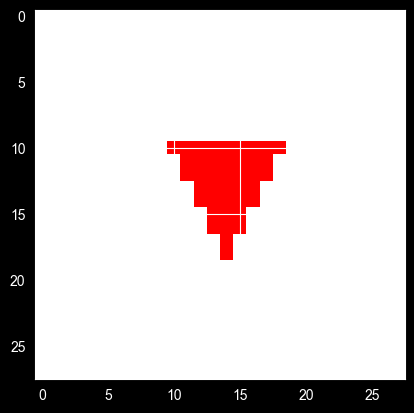

In [32]:
plt.imshow(images[ 0 ])

In [33]:
to_tensor = transforms.ToTensor( )
images_tensor = torch.stack([ to_tensor(image) for image in images ])

In [34]:
images_tensor

tensor([[[[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],

         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],

         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]]],


        [[[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
        

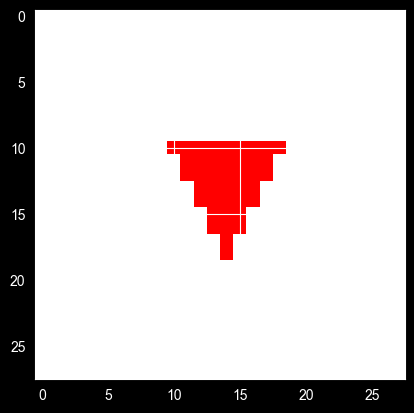

In [35]:
plt.imshow(images_tensor[ 0 ].permute(1 , 2 , 0).numpy( ))

In [36]:
images_tensor.shape

torch.Size([512, 3, 28, 28])

In [37]:
# ─────────────────────────────────────────────────────────────
# 1. EMA (Exponential Moving Average) pour stabiliser l'entraînement
# ─────────────────────────────────────────────────────────────
class EMA :
    """
    Maintient une version lissée des poids du modèle.
    Decay typique : 0.9999 (DDPM original)
    """

    def __init__(self , model: nn.Module , decay: float = 0.9999) :
        self.model = model
        self.decay = decay
        self.shadow = { k : v.clone( ).detach( ) for k , v in model.state_dict( ).items( ) }
        self.backup = { }

    def update(self) :
        """Met à jour les poids shadow après chaque step"""
        for name , param in self.model.named_parameters( ) :
            if param.requires_grad :
                self.shadow[ name ].lerp_(param , 1 - self.decay)

    def store(self) :
        """Sauvegarde les poids actuels (avant swap)"""
        self.backup = {
                k : v.clone( ).detach( ) for k , v in self.model.state_dict( ).items( )
        }

    def restore(self) :
        """Restaure les poids originaux (après swap)"""
        for name , param in self.model.named_parameters( ) :
            if name in self.backup :
                param.data.copy_(self.backup[ name ])
        self.backup = { }

    def apply_shadow(self) :
        """Applique les poids EMA au modèle (pour l'inférence)"""
        for name , param in self.model.named_parameters( ) :
            if name in self.shadow :
                param.data.copy_(self.shadow[ name ])

In [38]:
# ─────────────────────────────────────────────────────────────
# 2. Fonction de perte (L_simple du papier DDPM)
# ─────────────────────────────────────────────────────────────
def ddpm_loss(
        model: nn.Module ,
        schedule: DiffusionSchedule ,
        x0: torch.Tensor ,
        t: Optional[ torch.Tensor ] = None
) -> torch.Tensor :
    """
    Calcule L_simple = E[||ε - ε_θ(x_t, t)||²]

    Args:
        x0: (B, C, H, W) - images originales normalisées [-1, 1]
        t: timesteps optionnels, sinon tirés aléatoirement
    """
    B = x0.shape[ 0 ]
    if t is None :
        t = torch.randint(0 , schedule.T , (B ,) , device=x0.device)

    # Forward diffusion
    xt , noise = q_sample(schedule , x0 , t)

    # Prédiction du bruit
    epsilon_pred = model(xt , t)

    # MSE loss
    return nn.functional.mse_loss(epsilon_pred , noise)

In [44]:
# ─────────────────────────────────────────────────────────────
# 3. Boucle d'entraînement principale
# ─────────────────────────────────────────────────────────────
def train_ddpm(
        model: nn.Module ,
        schedule: DiffusionSchedule ,
        dataloader: DataLoader ,
        epochs: int ,
        lr: float = 2e-4 ,
        device: torch.device = None ,
        ema_decay: float = 0.9999 ,
        log_every: int = 100 ,
        sample_every: int = 1000 ,
        save_path: Optional[ str ] = None ,
) :
    """
    Entraîne un modèle DDPM complet.

    Args:
        model: UNet ou autre architecture compatible
        dataloader: DataLoader avec images normalisées [-1, 1]
        epochs: nombre d'époques
        lr: learning rate (Adam par défaut)
        ema_decay: facteur de lissage EMA
        log_every: fréquence de logging (en steps)
        sample_every: fréquence de génération d'échantillons
    """
    if device is None :
        device = torch.device("cuda" if torch.cuda.is_available( ) else "cpu")
    # Create save directory if needed
    if save_path :
        import os
        save_dir = os.path.dirname(save_path)
        if save_dir :  # Only create if path contains a directory component
            os.makedirs(save_dir , exist_ok=True)

    model = model.to(device)
    schedule = schedule.to(device)

    # Optimizer (valeurs par défaut du papier)
    optimizer = torch.optim.Adam(
            model.parameters( ) , lr=lr , betas=(0.9 , 0.999) , eps=1e-8
    )

    # EMA pour l'inférence
    ema = EMA(model , decay=ema_decay)

    # Tracking
    global_step = 0
    losses = [ ]

    print(f"🚀 Training on {device} | Steps/epoch: {len(dataloader)}")

    for epoch in range(epochs) :
        model.train( )
        pbar = tqdm(dataloader , desc=f"Epoch {epoch + 1}/{epochs}")

        for batch in pbar :
            # Gestion flexible du batch (dict ou tensor)
            if isinstance(batch , dict) :
                x0 = batch[ 'image' ] if 'image' in batch else list(batch.values( ))[ 0 ]
            else :
                x0 = batch

            x0 = x0.to(device)

            # Normalisation [-1, 1] si nécessaire
            if x0.max( ) <= 1.0 and x0.min( ) >= 0.0 :
                x0 = x0 * 2 - 1

            # Forward + backward
            optimizer.zero_grad( )
            loss = ddpm_loss(model , schedule , x0)
            loss.backward( )

            # Gradient clipping (stabilité)
            torch.nn.utils.clip_grad_norm_(model.parameters( ) , max_norm=1.0)

            optimizer.step( )
            ema.update( )  # Mise à jour EMA

            # Logging
            losses.append(loss.item( ))
            if global_step % log_every == 0 :
                avg_loss = sum(losses[ -log_every : ]) / len(losses[ -log_every : ])
                pbar.set_postfix({ 'loss' : f'{avg_loss:.4f}' , 'step' : global_step })

            # Sampling de test périodique
            if global_step % sample_every == 0 and global_step > 0 :
                model.eval( )
                ema.apply_shadow( )  # Utilise les poids EMA

                with torch.no_grad( ) :
                    samples = p_sample_loop(
                            model , schedule ,
                            shape=(4 , 3 , 28 , 28) ,
                            device=device ,
                            progress=False
                    )
                    # Ici: sauvegarder/visualiser samples
                    # save_images(samples, f"samples_step_{global_step}.png")

                ema.restore( )  # Retour aux poids d'entraînement
                model.train( )

            global_step += 1

        # Sauvegarde périodique
        if save_path and (epoch + 1) % 10 == 0 :
            torch.save({
                    'epoch' : epoch ,
                    'model_state' : model.state_dict( ) ,
                    'ema_state' : ema.shadow ,
                    'optimizer_state' : optimizer.state_dict( ) ,
                    'losses' : losses ,
            } , f"{save_path}_epoch{epoch + 1}.pt")

    return model , ema , losses

In [45]:
# Config
DEVICE = torch.device("cuda" if torch.cuda.is_available( ) else "cpu")
IMAGE_SHAPE = (3 , 28 , 28)
BATCH_SIZE = 128
EPOCHS = 100
T = 1000

# Components
schedule = DiffusionSchedule(T=T).to(DEVICE)
model = UNet(in_channels=3 , out_channels=3 , base_channels=64).to(DEVICE)
dataloader = DataLoader(
        images_tensor ,
        batch_size=128 ,
        shuffle=True ,
        num_workers=0 ,
        pin_memory=True ,
)

print(f"📊 UNet params: {sum(p.numel( ) for p in model.parameters( )):,}")

# Train!
trained_model , ema , losses = train_ddpm(
        model=model ,
        schedule=schedule ,
        dataloader=dataloader ,
        epochs=EPOCHS ,
        lr=2e-4 ,
        device=DEVICE ,
        ema_decay=0.9999 ,
        log_every=50 ,
        sample_every=500 ,
        save_path="./checkpoints/ddpm_mnist"
)

# Génération finale avec poids EMA
print("🎨 Génération d'échantillons finaux...")
ema.apply_shadow( )
trained_model.eval( )

with torch.no_grad( ) :
    final_samples = p_sample_loop(
            trained_model , schedule ,
            shape=(8 , 3 , 28 , 28) ,
            device=DEVICE ,
            progress=True
    )

# Sauvegarde (à adapter avec PIL/torchvision)
# save_images(final_samples, "final_samples.png")
print("✅ Terminé !")

📊 UNet params: 23,937,091
🚀 Training on cpu | Steps/epoch: 4


Epoch 26/100:  50%|█████     | 2/4 [00:26<00:26, 13.27s/it, loss=0.0817, step=100]


KeyboardInterrupt: 